# Bemessung von Bohrpfählen — Schritt für Schritt
## Längs- und Querbewehrung nach DIN EN 1536, DIN EN 1997-1 / DIN 1054 und DIN EN 1992-1-1

---

### Zugrunde gelegte Normen

| Kurz | Norm | Inhalt |
|---|---|---|
| **EN 1536** | `DIN EN 1536:2015-10` | *Ausführung von Arbeiten im Spezialtiefbau — Bohrpfähle*: Betondeckung, Mindestbewehrung, Bewehrungskorb |
| **EC7** | `DIN EN 1997-1:2009-09` + `/NA` | *Eurocode 7: Entwurf, Berechnung und Bemessung in der Geotechnik* |
| **DIN 1054** | `DIN 1054:2010-12` (+A1:2012-08) | *Baugrund — Sicherheitsnachweise im Erd- und Grundbau*, Teilsicherheitsbeiwerte |
| **EA-Pfähle** | Empfehlungen des Arbeitskreises „Pfähle“ (DGGT), 2. Auflage | Erfahrungswerte $q_{b,k}$/$q_{s,k}$, Widerstands-Setzungs-Linie, Bettungsmodulverfahren |
| **EC2** | `DIN EN 1992-1-1:2011-01` + `/NA:2013-04` | Querschnittsbemessung (M-N-Interaktion, Querkraft) |
| **EC0** | `DIN EN 1990:2010-12` + `/NA` | Einwirkungskombinationen |

Weitere Ausführungsnormen (hier nicht behandelt): `DIN EN 12699` Verdrängungspfähle,
`DIN EN 14199` Mikropfähle.

---

### Aufbau

Jeder Abschnitt nennt den **DIN-Abschnitt**, gibt die **Gleichung** in Normschreibweise an,
rechnet sie **von Hand in Python** nach, gleicht sie mit dem Modul `din_pfahl` ab und zeigt
die zugehörige **Grafik**.

> ⚠️ **Wichtig**: $q_{b,k}$ und $q_{s,k}$ sind **Eingabewerte des Anwenders**. Sie sind den
> Tabellen 5.12 bis 5.15 der EA-Pfähle (in Abhängigkeit von $q_c$ bzw. $c_u$) oder einer
> Probebelastung zu entnehmen. Dieses Material enthält bewusst **keine** Erfahrungswerte-Tabellen.
>
> Nicht erfasst: Pfahlgruppenwirkung, negative Mantelreibung, zyklische und dynamische
> Einwirkungen, Erdbeben.

In [1]:
# --- Arbeitsumgebung ---------------------------------------------------------
import os, sys, math
import numpy as np
import matplotlib.pyplot as plt

for _p in (os.getcwd(), os.path.dirname(os.getcwd())):
    if os.path.isdir(os.path.join(_p, "din_pfahl")) and _p not in sys.path:
        sys.path.insert(0, _p)

from din_balken.baustoffe import Beton, Betonstahl, stabflaeche
from din_pfahl.kreisquerschnitt import (Kreisquerschnitt, interaktionsdiagramm,
                                        M_Rd_bei_N, schnittgroessen_bei_x,
                                        dehnungsebene, mindestbewehrung_pfahl,
                                        mindestbewehrung_druckglied,
                                        betondeckung_pfahl, konstruktive_pruefung,
                                        erforderliche_bewehrung)
from din_pfahl.bettung import (Bodenschicht, pfahl_horizontal, bettungsmodul,
                               knicklast_gebettet)
from din_pfahl.tragfaehigkeit import (axiale_tragfaehigkeit, GAMMA_R,
                                      widerstands_setzungs_linie,
                                      pfahlkopfsetzung)
from din_pfahl.bemessung_pfahl import (EingabePfahl, bemessung_pfahl,
                                       bericht_text, querkraft_kreis)
from din_pfahl.normen_pfahl import normentabelle
from din_pfahl import grafiken_pfahl as GP
from din_balken import grafiken as G

plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
                     "font.size": 10, "figure.dpi": 100})
print("Umgebung bereit — din_pfahl geladen aus:",
      os.path.dirname(sys.modules["din_pfahl"].__file__))

Umgebung bereit — din_pfahl geladen aus: C:\Users\CESAR FERNANDO\Desktop\Programs\BetonPlännen\din_pfahl


---
# Schritt 0 · Aufgabenstellung

Durchgerechnetes Beispiel: **Bohrpfahl einer Hochbaugründung**, axial und horizontal belastet.

| Größe | Wert |
|---|---|
| Pfahldurchmesser | $D = 900$ mm |
| Pfahllänge | $L = 15{,}0$ m |
| Beton | **C25/30** `[DIN EN 1536, 6.3]` |
| Betonstahl | **B500B** `[DIN 488-1]` |
| $N_{Ed}$ (Druck) | $-2500$ kN |
| $N_k$ (charakteristisch) | $-1850$ kN |
| $H_{Ed}$ | $150$ kN |
| Bemessungssituation | **BS-P** `[DIN 1054, Tab. A 2.3]` |

**Baugrund** (Erfahrungswerte nach EA-Pfähle als Eingabe):

| Schicht | $z_o$ [m] | $z_u$ [m] | $E_s$ [kN/m²] | $q_{s,k}$ [kN/m²] |
|---|---|---|---|---|
| Auffüllung / Weichschicht | 0,0 | 4,0 | 8 000 | 30 |
| Sand, mitteldicht | 4,0 | 10,0 | 25 000 | 70 |
| Sand, dicht | 10,0 | 15,0 | 60 000 | 120 |

Spitzendruck $q_{b,k} = 1800$ kN/m².

In [2]:
# --- Ausgangswerte -----------------------------------------------------------
D      = 900.0     # mm   Pfahldurchmesser
L      = 15.0      # m    Pfahllänge
D_m    = D/1000.0

betonklasse = "C25/30"
stahlsorte  = "B500B"
d_g         = 16.0

N_Ed   = -2500.0   # kN   Bemessungswert, DRUCK NEGATIV
N_k    = -1850.0   # kN   charakteristisch (für die Setzung)
H_Ed   =  150.0    # kN
M_kopf =    0.0    # kNm
situation = "BS-P"

q_b_k  = 1800.0    # kN/m²  Spitzendruck (EA-Pfähle, Eingabewert)

schichten = [
    Bodenschicht(0.0,  4.0, E_s= 8000., q_s_k= 30., c_u_k=25., name="Weichschicht"),
    Bodenschicht(4.0, 10.0, E_s=25000., q_s_k= 70., phi_k=32.5, name="Sand mitteldicht"),
    Bodenschicht(10.0, 15.0, E_s=60000., q_s_k=120., phi_k=37.5, name="Sand dicht"),
]

phi_l = 20.0       # mm   Längsstabdurchmesser
phi_w = 10.0       # mm   Wendeldurchmesser

C = Beton(betonklasse, d_g=d_g)
S = Betonstahl(stahlsorte)
print(f"Bohrpfahl D = {D:.0f} mm, L = {L:.1f} m, {betonklasse}, {stahlsorte}")
print(f"N_Ed = {N_Ed:.0f} kN | H_Ed = {H_Ed:.0f} kN | Bemessungssituation {situation}")

Bohrpfahl D = 900 mm, L = 15.0 m, C25/30, B500B
N_Ed = -2500 kN | H_Ed = 150 kN | Bemessungssituation BS-P


---
# Schritt 1 · Baustoffe und Betondeckung

## 1.1 Beton — `[EC2 3.1 ; DIN EN 1536, 6.3]`

$$f_{cd}=\alpha_{cc}\,\frac{f_{ck}}{\gamma_C}=0{,}85\,\frac{f_{ck}}{1{,}50}
\qquad\text{`[EC2 3.1.6 (1)P, Gl. (3.15) + NA NDP zu 3.1.6 (1)P]`}$$

`DIN EN 1536, 6.3` fordert für Pfahlbeton eine **weiche bis fließfähige Konsistenz**
(Verarbeitbarkeit im Bohrloch), Größtkorn $\le$ 32 mm und einen Mindestzementgehalt;
üblich ist mindestens **C25/30**.

## 1.2 Betondeckung — `[DIN EN 1536, 7.6.2]`

$$c_{nom}\ \ge\ \begin{cases}
60\ \text{mm} & D\ \ge\ 0{,}6\ \text{m}\\
50\ \text{mm} & D\ <\ 0{,}6\ \text{m}\\
75\ \text{mm} & \text{Betonage unter Stützflüssigkeit}
\end{cases}$$

> Diese Werte liegen deutlich über den Anforderungen des EC2 für Hochbauteile, weil der
> Beton gegen den anstehenden Boden betoniert wird und der Bewehrungskorb Lagetoleranzen hat.

## 1.3 Bewehrungskreis

$$D_s = D - 2\,(c_{nom}+\varnothing_w) - \varnothing_l$$

In [3]:
bdk = betondeckung_pfahl(D, unter_stuetzfluessigkeit=False)
c_nom = bdk["c_nom"]
print(f"BETON {betonklasse}")
print(f"  f_ck = {C.fck:.1f} N/mm²   f_ctm = {C.fctm:.2f} N/mm²   E_cm = {C.Ecm:.0f} N/mm²")
print(f"  f_cd = 0,85·{C.fck:.0f}/1,50 = {C.fcd:.2f} N/mm²   [EC2 Gl. (3.15) + NA]")
print(f"  ε_c2 = {C.eps_c2:.2f} ‰   ε_cu2 = {C.eps_cu2:.2f} ‰")
print(f"\nBETONSTAHL {S.sorte}: f_yd = {S.fyd:.2f} N/mm²   ε_ud = {S.eps_ud:.0f} ‰")
print(f"\nBETONDECKUNG  [DIN EN 1536, 7.6.2]")
print(f"  D = {D:.0f} mm ≥ 600 mm  →  c_nom = {c_nom:.0f} mm")

qs = Kreisquerschnitt(D=D, c_nom=c_nom, phi_l=phi_l, n_l=8, phi_w=phi_w)
print(f"\n  A_c = π D²/4 = {qs.Ac:.0f} mm² = {qs.Ac/1e6:.4f} m²")
print(f"  D_s = D - 2(c_nom + φ_w) - φ_l = {D:.0f} - 2({c_nom:.0f}+{phi_w:.0f}) - {phi_l:.0f}"
      f" = {qs.D_s:.0f} mm")
print(f"  U   = π D = {math.pi*D_m:.3f} m      A_b = π D²/4 = {math.pi*D_m**2/4:.4f} m²")

BETON C25/30
  f_ck = 25.0 N/mm²   f_ctm = 2.56 N/mm²   E_cm = 31476 N/mm²
  f_cd = 0,85·25/1,50 = 14.17 N/mm²   [EC2 Gl. (3.15) + NA]
  ε_c2 = 2.00 ‰   ε_cu2 = 3.50 ‰

BETONSTAHL B500B: f_yd = 434.78 N/mm²   ε_ud = 25 ‰

BETONDECKUNG  [DIN EN 1536, 7.6.2]
  D = 900 mm ≥ 600 mm  →  c_nom = 60 mm

  A_c = π D²/4 = 636173 mm² = 0.6362 m²
  D_s = D - 2(c_nom + φ_w) - φ_l = 900 - 2(60+10) - 20 = 740 mm
  U   = π D = 2.827 m      A_b = π D²/4 = 0.6362 m²


---
# Schritt 2 · Axiale Pfahltragfähigkeit — `[DIN EN 1997-1, 7.6 + DIN 1054, A 7.6]`

## 2.1 Charakteristischer Widerstand — `Gl. (7.8)`

$$R_{c,k}=R_{b,k}+R_{s,k}=q_{b,k}\,A_b+\sum_i q_{s,k,i}\,A_{s,i}$$

mit $A_b=\pi D^2/4$ und $A_{s,i}=\pi D\,\Delta l_i$.

## 2.2 Bemessungswert — `[DIN 1054, A 7.6.2.2, Tab. A 2.3]`

$$\boxed{\ R_{c,d}=\frac{R_{b,k}}{\gamma_b}+\frac{R_{s,k}}{\gamma_s}\ }$$

| Bemessungssituation | $\gamma_b$ | $\gamma_s$ | $\gamma_{s,t}$ (Zug) |
|---|---|---|---|
| **BS-P** (ständig) | 1,10 | 1,10 | 1,15 |
| **BS-T** (vorübergehend) | 1,10 | 1,10 | 1,15 |
| **BS-A** (außergewöhnlich) | 1,00 | 1,00 | 1,10 |

## 2.3 Nachweis (GEO-2)

$$F_{c,d}\ \le\ R_{c,d}$$

Die Einwirkung $F_{c,d}$ folgt aus `[EC0 Gl. (6.10)]` mit $\gamma_G=1{,}35$, $\gamma_Q=1{,}50$
`[DIN 1054, Tab. A 2.1]`.

In [4]:
U  = math.pi * D_m
Ab = math.pi * D_m**2 / 4.0

print(f"{'Schicht':<20s}{'z_o':>7s}{'z_u':>7s}{'Δl':>7s}{'q_s,k':>9s}{'A_s [m²]':>11s}{'R_s,k [kN]':>12s}")
print("-"*73)
R_s_k = 0.0
for s in schichten:
    dl = s.z_u - s.z_o
    A_s = U * dl
    R_i = s.q_s_k * A_s
    R_s_k += R_i
    print(f"{s.name:<20s}{s.z_o:>7.2f}{s.z_u:>7.2f}{dl:>7.2f}{s.q_s_k:>9.0f}"
          f"{A_s:>11.3f}{R_i:>12.0f}")
print("-"*73)
print(f"{'Σ Mantelreibung':<20s}{'':>34s}{R_s_k:>12.0f}")

R_b_k = q_b_k * Ab
R_c_k = R_b_k + R_s_k
g = GAMMA_R[situation]
R_c_d = R_b_k/g["gamma_b"] + R_s_k/g["gamma_s"]
F_c_d = abs(N_Ed)

print(f"\n  R_b,k = q_b,k·A_b = {q_b_k:.0f}·{Ab:.4f} = {R_b_k:.0f} kN")
print(f"  R_c,k = {R_b_k:.0f} + {R_s_k:.0f} = {R_c_k:.0f} kN        [Gl. (7.8)]")
print(f"\n  γ_b = {g['gamma_b']:.2f} ; γ_s = {g['gamma_s']:.2f} ; γ_s,t = {g['gamma_s_t']:.2f}"
      f"   [DIN 1054, Tab. A 2.3, {situation}]")
print(f"  R_c,d = {R_b_k:.0f}/{g['gamma_b']:.2f} + {R_s_k:.0f}/{g['gamma_s']:.2f} = {R_c_d:.0f} kN")
print(f"\n  NACHWEIS: F_c,d = {F_c_d:.0f} kN {'≤' if F_c_d<=R_c_d else '>'} R_c,d = {R_c_d:.0f} kN"
      f"   →  η = {F_c_d/R_c_d:.3f}  {'ERFÜLLT' if F_c_d<=R_c_d else 'NICHT ERFÜLLT'}")

trag = axiale_tragfaehigkeit(D_m, schichten, q_b_k, F_c_d, situation=situation, L_pfahl=L)
print(f"\n  din_pfahl: R_s,k = {trag.R_s_k:.0f} kN | R_b,k = {trag.R_b_k:.0f} kN"
      f" | R_c,d = {trag.R_c_d:.0f} kN")

Schicht                 z_o    z_u     Δl    q_s,k   A_s [m²]  R_s,k [kN]
-------------------------------------------------------------------------
Weichschicht           0.00   4.00   4.00       30     11.310         339
Sand mitteldicht       4.00  10.00   6.00       70     16.965        1188
Sand dicht            10.00  15.00   5.00      120     14.137        1696
-------------------------------------------------------------------------
Σ Mantelreibung                                               3223

  R_b,k = q_b,k·A_b = 1800·0.6362 = 1145 kN
  R_c,k = 1145 + 3223 = 4368 kN        [Gl. (7.8)]

  γ_b = 1.10 ; γ_s = 1.10 ; γ_s,t = 1.15   [DIN 1054, Tab. A 2.3, BS-P]
  R_c,d = 1145/1.10 + 3223/1.10 = 3971 kN

  NACHWEIS: F_c,d = 2500 kN ≤ R_c,d = 3971 kN   →  η = 0.630  ERFÜLLT

  din_pfahl: R_s,k = 3223 kN | R_b,k = 1145 kN | R_c,d = 3971 kN


## 2.4 Widerstands-Setzungs-Linie — `[EA-Pfähle, 5.4.5]`

Charakteristische Grenzsetzungen für Bohrpfähle:

$$s_{sg}\,[\text{cm}] = 0{,}50\,R_{s,k}\,[\text{MN}] + 0{,}50\ \text{cm}\ ,\qquad s_{sg}\le 3{,}0\ \text{cm}$$
$$s_g = 0{,}10\,D$$

$s_{sg}$ ist die Setzung, bei der die **volle Mantelreibung** mobilisiert ist; $s_g$ diejenige,
bei der der **volle Spitzendruck** erreicht wird. Zwischen 0 und den Grenzsetzungen wird hier
vereinfacht **linear** interpoliert (die EA-Pfähle geben gekrümmte Verläufe an).

In [5]:
s_sg = min(0.5*(R_s_k/1000.0) + 0.5, 3.0)     # cm
s_g  = 0.10 * D_m * 100.0                      # cm
print(f"  s_sg = 0,5·{R_s_k/1000:.3f} MN + 0,5 cm = {0.5*(R_s_k/1000)+0.5:.2f} cm"
      f"  →  begrenzt auf {s_sg:.2f} cm = {s_sg*10:.1f} mm")
print(f"  s_g  = 0,10·D = {s_g:.2f} cm = {s_g*10:.1f} mm")

wsl = widerstands_setzungs_linie(D_m, R_b_k, R_s_k)
setzung = pfahlkopfsetzung(wsl, abs(N_k))
print(f"\n  Setzung bei N_k = {abs(N_k):.0f} kN:  s = {setzung:.1f} mm")

  s_sg = 0,5·3.223 MN + 0,5 cm = 2.11 cm  →  begrenzt auf 2.11 cm = 21.1 mm
  s_g  = 0,10·D = 9.00 cm = 90.0 mm

  Setzung bei N_k = 1850 kN:  s = 11.2 mm


---
# Schritt 3 · Horizontal belasteter Pfahl — `[EA-Pfähle, 6.3]`

## 3.1 Bettungsmodulverfahren

Der Pfahl wird als **elastisch gebetteter Balken** (Winkler) abgebildet:

$$EI\,w''''(z)+k_s(z)\,D\,w(z)=0$$

Bettungsmodul nach `[EA-Pfähle, 6.3]`:

$$k_s=\frac{E_s}{D}\ \ (D\le 1{,}0\ \text{m})\ ,\qquad
k_s=\frac{E_s}{1{,}0\ \text{m}}\ \ (D>1{,}0\ \text{m})$$

Kennwert der **elastischen Länge**:

$$\lambda=\sqrt[4]{\frac{k_s\,D}{4\,EI}}\qquad\Rightarrow\qquad
\text{langer Pfahl, wenn } L\,\lambda\ \gtrsim\ 2{,}5$$

Für den langen Pfahl mit freiem Kopf und Horizontalkraft $H$ gelten die geschlossenen Lösungen

$$w(0)=\frac{2H\lambda}{k}\qquad M_{max}=0{,}3224\,\frac{H}{\lambda}\ \ \text{bei}\ \ z=\frac{\pi}{4\lambda}$$

die hier zur Kontrolle der numerischen Lösung dienen ($k=k_s D$).

## 3.2 Ansatz der Biegesteifigkeit

Der Pfahl reißt unter Biegung; üblich ist ein Ansatz $EI \approx 0{,}5\,E_{cm}I_b$ (Zustand II).

In [6]:
EI_b = C.Ecm * (math.pi * D**4 / 64.0) / 1e9     # kNm²
EI   = 0.5 * EI_b
ks_0 = bettungsmodul(schichten[0].E_s, D_m)
k_0  = ks_0 * D_m
lam  = (k_0/(4*EI))**0.25

print(f"  I_b = π D⁴/64 = {math.pi*D**4/64:.4g} mm⁴")
print(f"  EI_brutto = {EI_b/1000:.1f} MNm²  →  EI (Zustand II, 0,5·EI_b) = {EI/1000:.1f} MNm²")
print(f"  k_s (oberste Schicht) = E_s/D = {schichten[0].E_s:.0f}/{D_m:.1f} = {ks_0:.0f} kN/m³")
print(f"  k = k_s·D = {k_0:.0f} kN/m²")
print(f"  λ = (k/(4EI))^0,25 = {lam:.4f} 1/m   →  1/λ = {1/lam:.2f} m ; L·λ = {L*lam:.2f}")
print(f"  →  {'langer (elastischer) Pfahl' if L*lam>2.5 else 'kurzer (starrer) Pfahl'}")

hor = pfahl_horizontal(L, D_m, EI, schichten, H=H_Ed, M_kopf=M_kopf, kopf="frei")
print(f"\n  Numerisch (geschichteter Boden):")
print(f"     w_Kopf = {hor.w_kopf:.2f} mm")
print(f"     M_max  = {hor.M_max:.1f} kNm bei z = {hor.z_Mmax:.2f} m")
print(f"     V_max  = {hor.V_max:.1f} kN")
print(f"\n  Kontrolle mit der geschlossenen Lösung (homogener Boden, E_s der 1. Schicht):")
print(f"     w_Kopf = 2Hλ/k   = {2*H_Ed*lam/k_0*1000:.2f} mm")
print(f"     M_max  = 0,3224H/λ = {0.3224*H_Ed/lam:.1f} kNm bei z = {math.pi/(4*lam):.2f} m")
print("     (Abweichung durch die steiferen unteren Schichten — plausibel)")

  I_b = π D⁴/64 = 3.221e+10 mm⁴
  EI_brutto = 1013.7 MNm²  →  EI (Zustand II, 0,5·EI_b) = 506.9 MNm²
  k_s (oberste Schicht) = E_s/D = 8000/0.9 = 8889 kN/m³
  k = k_s·D = 8000 kN/m²
  λ = (k/(4EI))^0,25 = 0.2506 1/m   →  1/λ = 3.99 m ; L·λ = 3.76
  →  langer (elastischer) Pfahl

  Numerisch (geschichteter Boden):
     w_Kopf = 9.08 mm
     M_max  = 206.5 kNm bei z = 3.52 m
     V_max  = 147.3 kN

  Kontrolle mit der geschlossenen Lösung (homogener Boden, E_s der 1. Schicht):
     w_Kopf = 2Hλ/k   = 9.40 mm
     M_max  = 0,3224H/λ = 193.0 kNm bei z = 3.13 m
     (Abweichung durch die steiferen unteren Schichten — plausibel)


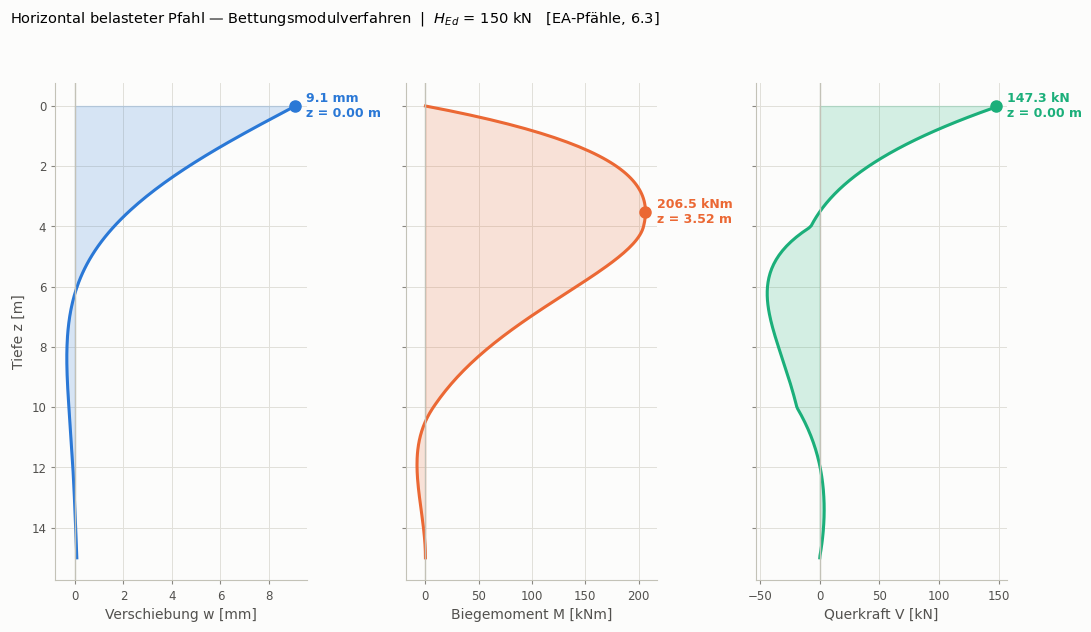

In [7]:
# --- GRAFIK: Verläufe w(z), M(z), V(z) --------------------------------------
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(11, 6.4), sharey=True)
for ax, wert, farbe, lab, einh in ((a1, hor.w, G.C1, "Verschiebung w", "mm"),
                                   (a2, hor.M, G.C2, "Biegemoment M", "kNm"),
                                   (a3, hor.V, G.C3, "Querkraft V", "kN")):
    ax.plot(wert, -hor.z, color=farbe, lw=2.2)
    ax.fill_betweenx(-hor.z, 0, wert, color=farbe, alpha=0.18)
    ax.axvline(0, color=G.AXIS, lw=1.0)
    j = int(np.argmax(np.abs(wert)))
    ax.plot([wert[j]], [-hor.z[j]], "o", color=farbe, ms=8)
    ax.annotate(f"{wert[j]:.1f} {einh}\nz = {hor.z[j]:.2f} m", (wert[j], -hor.z[j]),
                textcoords="offset points", xytext=(8, 0), color=farbe, fontsize=9,
                va="center", fontweight="bold")
    ax.set_xlabel(f"{lab} [{einh}]"); G._stil(ax, grid="both")
a1.set_ylabel("Tiefe z [m]")
a1.set_yticks(np.arange(0, -L-1, -2)); a1.set_yticklabels([f"{abs(v):.0f}" for v in np.arange(0, -L-1, -2)])
fig.suptitle(f"Horizontal belasteter Pfahl — Bettungsmodulverfahren  |  $H_{{Ed}}$ = {H_Ed:.0f} kN"
             "   [EA-Pfähle, 6.3]", fontsize=10.5, x=0.012, ha="left")
plt.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()

---
# Schritt 4 · Längsbewehrung: M-N-Interaktion — `[EC2 6.1]`

## 4.1 Dehnungsdiagramm des Kreisquerschnitts

Der Kreisquerschnitt wird mit dem **vollständigen Dehnungsdiagramm** nach `EC2 6.1 (2)P, Bild 6.1`
abgebildet — drei Bemessungspunkte:

| Punkt | Bereich | Bedingung |
|---|---|---|
| **A** | $x\le x_A$ | Stahl maßgebend: $\varepsilon_s = \varepsilon_{ud} = 25‰$ |
| **B** | $x_A < x \le D$ | Beton maßgebend: $\varepsilon_c = \varepsilon_{cu2} = 3{,}5‰$ |
| **C** | $x > D$ | überdrückt: $\varepsilon = \varepsilon_{c2}$ im Abstand $y_C$ vom Druckrand |

mit `[EC2 6.1 (5)]`:
$$y_C=\left(1-\frac{\varepsilon_{c2}}{\varepsilon_{cu2}}\right)D
=\left(1-\frac{2{,}0}{3{,}5}\right)D=0{,}4286\,D$$

## 4.2 Integration über die Kreisfläche

Die Breite des Kreises in der Tiefe $y$ ab dem gedrückten Rand beträgt

$$b(y)=2\sqrt{y\,(D-y)}$$

Damit:
$$F_{cd}=\int_0^{\min(x,D)}\sigma_c\big(\varepsilon(y)\big)\,b(y)\,dy
\qquad
F_{si}=A_{s,i}\big[\sigma_s(\varepsilon_i)-\sigma_c(\varepsilon_i)\big]$$

(der von den Druckstäben **verdrängte Beton** wird abgezogen)

$$N_{Rd}=-\Big(F_{cd}+\sum F_{si}\Big)
\qquad
M_{Rd}=F_{cd}\left(\frac{D}{2}-y_c\right)+\sum F_{si}\left(\frac{D}{2}-y_i\right)$$

Durchfahren aller Nulllinienlagen $x$ liefert das **M-N-Interaktionsdiagramm**.

In [8]:
# --- Eckwerte von Hand nachrechnen ------------------------------------------
n_l = 8
qs = Kreisquerschnitt(D=D, c_nom=c_nom, phi_l=phi_l, n_l=n_l, phi_w=phi_w)
As_ges = qs.As_ges

# zentrischer Zug: alle Stäbe auf f_yd
N_zug_h = As_ges * S.fyd / 1e3
# zentrischer Druck: Beton auf f_cd, Stahl bei ε_c2
N_druck_h = -(qs.Ac*C.fcd + As_ges*(S.sigma_s(C.eps_c2) - C.fcd))/1e3
y_C = (1 - C.eps_c2/C.eps_cu2) * D

print(f"  {n_l} ⌀{phi_l:.0f} = {As_ges:.0f} mm²   ρ = A_s/A_c = {100*qs.rho_l:.2f} %")
print(f"\n  Bemessungspunkt C: y_C = (1 - {C.eps_c2:.1f}/{C.eps_cu2:.1f})·D = {y_C:.1f} mm"
      f"  = {y_C/D:.4f}·D   [EC2 6.1 (5)]")
print(f"\n  zentrischer Zug  : N_Rd = A_s·f_yd = {N_zug_h:.0f} kN")
print(f"  zentrischer Druck: N_Rd = -(A_c f_cd + A_s(σ_s(ε_c2) - f_cd)) = {N_druck_h:.0f} kN")

diag = interaktionsdiagramm(qs, C, S, n_punkte=300)
print(f"\n  din_pfahl: N_Zug = {diag['N_zug']:.0f} kN | N_Druck = {diag['N_druck_max']:.0f} kN"
      f" | M_Rd,max = {diag['M_max']:.1f} kNm")

M_Ed = max(hor.M_max, abs(M_kopf))
M_Rd = M_Rd_bei_N(diag, N_Ed)
print(f"\n  NACHWEIS bei N_Ed = {N_Ed:.0f} kN:")
print(f"     M_Rd = {M_Rd:.1f} kNm {'≥' if M_Rd>=M_Ed else '<'} M_Ed = {M_Ed:.1f} kNm"
      f"   →  η = {M_Ed/M_Rd:.3f}  {'ERFÜLLT' if M_Rd>=M_Ed else 'NICHT ERFÜLLT'}")

  8 ⌀20 = 2513 mm²   ρ = A_s/A_c = 0.40 %

  Bemessungspunkt C: y_C = (1 - 2.0/3.5)·D = 385.7 mm  = 0.4286·D   [EC2 6.1 (5)]

  zentrischer Zug  : N_Rd = A_s·f_yd = 1093 kN
  zentrischer Druck: N_Rd = -(A_c f_cd + A_s(σ_s(ε_c2) - f_cd)) = -9982 kN

  din_pfahl: N_Zug = 1093 kN | N_Druck = -9977 kN | M_Rd,max = 1036.7 kNm

  NACHWEIS bei N_Ed = -2500 kN:
     M_Rd = 936.4 kNm ≥ M_Ed = 206.5 kNm   →  η = 0.221  ERFÜLLT


In [9]:
# --- Einzelne Nulllinienlagen zeigen den Übergang A → B → C -----------------
print(f"{'x [mm]':>10s}{'x/D':>8s}{'Punkt':>7s}{'ε_Rand [‰]':>12s}"
      f"{'ε_Zug [‰]':>11s}{'N_Rd [kN]':>12s}{'M_Rd [kNm]':>12s}")
print("-"*72)
for x in (60., 150., 300., 450., 700., 900., 1500., 5000., 40000.):
    r = schnittgroessen_bei_x(qs, C, S, x)
    print(f"{x:>10.0f}{x/D:>8.2f}{r['punkt']:>7s}{r['eps_rand']:>12.2f}"
          f"{r['eps_zug']:>11.2f}{r['N_Rd']:>12.0f}{r['M_Rd']:>12.1f}")

    x [mm]     x/D  Punkt  ε_Rand [‰]  ε_Zug [‰]   N_Rd [kN]  M_Rd [kNm]
------------------------------------------------------------------------
        60    0.07      A        1.97     -25.00         851        97.3
       150    0.17      B        3.50     -15.63         -36       403.8
       300    0.33      B        3.50      -6.07       -1632       807.3
       450    0.50      B        3.50      -2.88       -3418      1023.4
       700    0.78      B        3.50      -0.60       -6447       857.8
       900    1.00      C        3.50       0.31       -8368       475.7
      1500    1.67      C        2.69       1.22       -9588       129.1
      5000    5.56      C        2.17       1.81       -9948        19.7
     40000   44.44      C        2.02       1.98       -9977         1.8


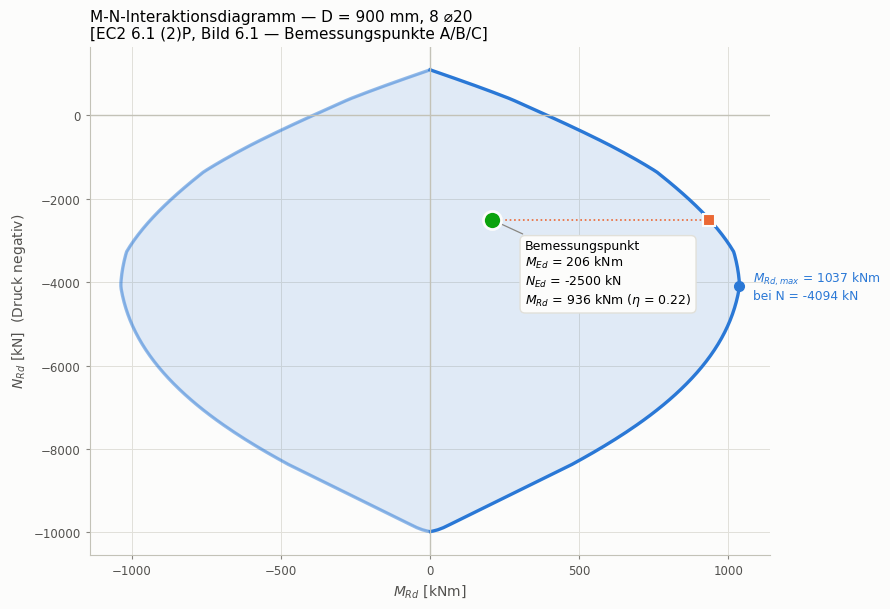

In [10]:
# --- GRAFIK: M-N-Interaktionsdiagramm ---------------------------------------
fig, ax = plt.subplots(figsize=(9, 6.2))
M2 = np.concatenate([diag["M"], -diag["M"][::-1]])
N2 = np.concatenate([diag["N"], diag["N"][::-1]])
ax.fill(M2, N2, color=G.C1, alpha=0.13)
ax.plot(diag["M"], diag["N"], color=G.C1, lw=2.4)
ax.plot(-diag["M"], diag["N"], color=G.C1, lw=2.4, alpha=0.5)
ax.axhline(0, color=G.AXIS, lw=1.0); ax.axvline(0, color=G.AXIS, lw=1.0)
i = int(np.argmax(diag["M"]))
ax.plot(diag["M"][i], diag["N"][i], "o", color=G.C1, ms=7)
ax.annotate(f"$M_{{Rd,max}}$ = {diag['M'][i]:.0f} kNm\nbei N = {diag['N'][i]:.0f} kN",
            (diag["M"][i], diag["N"][i]), textcoords="offset points", xytext=(10, 0),
            color=G.C1, fontsize=8.8, va="center")
ax.plot([M_Ed], [N_Ed], "o", color=G.OK if M_Ed <= M_Rd else G.NOK, ms=13,
        mec="#fcfcfb", mew=2, zorder=6)
ax.plot([M_Rd], [N_Ed], "s", color=G.C2, ms=9, mec="#fcfcfb", mew=1.5, zorder=6)
ax.plot([M_Ed, M_Rd], [N_Ed, N_Ed], color=G.C2, lw=1.2, ls=":")
ax.annotate(f"Bemessungspunkt\n$M_{{Ed}}$ = {M_Ed:.0f} kNm\n$N_{{Ed}}$ = {N_Ed:.0f} kN\n"
            f"$M_{{Rd}}$ = {M_Rd:.0f} kNm ($\\eta$ = {M_Ed/M_Rd:.2f})",
            (M_Ed, N_Ed), textcoords="offset points", xytext=(24, -60), fontsize=9,
            bbox=dict(fc="#fcfcfb", ec=G.GRID, boxstyle="round,pad=0.4"),
            arrowprops=dict(arrowstyle="->", color=G.MUT, lw=0.9))
ax.set_xlabel("$M_{Rd}$ [kNm]"); ax.set_ylabel("$N_{Rd}$ [kN]  (Druck negativ)")
ax.set_title(f"M-N-Interaktionsdiagramm — D = {D:.0f} mm, {n_l} ⌀{phi_l:.0f}\n"
             "[EC2 6.1 (2)P, Bild 6.1 — Bemessungspunkte A/B/C]", loc="left", fontsize=11)
G._stil(ax, grid="both"); plt.tight_layout(); plt.show()

---
# Schritt 5 · Mindestbewehrung und konstruktive Regeln

## 5.1 Mindestlängsbewehrung — `[DIN EN 1536, 7.6.3, Tabelle 4]`

$$A_{s,min}=\begin{cases}
0{,}50\ \%\ A_c & A_c\le 0{,}5\ \text{m}^2\\[2pt]
25\ \text{cm}^2 & 0{,}5\ \text{m}^2 < A_c\le 1{,}0\ \text{m}^2\\[2pt]
0{,}25\ \%\ A_c & A_c > 1{,}0\ \text{m}^2
\end{cases}$$

## 5.2 Mindestbewehrung von Druckgliedern — `[NA zu EC2, NDP zu 9.5.2 (2)]`

$$A_{s,min}=0{,}15\,\frac{|N_{Ed}|}{f_{yd}}$$

Maßgebend ist der **größere** der beiden Werte.

## 5.3 Konstruktive Anforderungen — `[DIN EN 1536, 7.6.3 / 7.6.4 ; EC2 9.5.3]`

* mindestens **6 Längsstäbe**, $\varnothing_l\ge 16$ mm
* lichter Stababstand $\ge 100$ mm (bzw. $\ge 80$ mm bei Größtkorn $\le 20$ mm) —
  der Beton muss durch den Korb fließen können
* Querbewehrung (Wendel oder Ringe): $\varnothing_w\ge 6$ mm und $\ge \varnothing_l/4$;
  Ganghöhe $100\ \text{mm}\le s\le 400$ mm

In [11]:
mb = mindestbewehrung_pfahl(qs)
mbd = mindestbewehrung_druckglied(N_Ed, S)
As_min = max(mb["As_min"], mbd["As_min"])
kon = konstruktive_pruefung(qs, d_g)

print(f"  A_c = {mb['Ac_m2']:.3f} m²  →  Regel: {mb['regel']}")
print(f"  A_s,min (EN 1536, Tab. 4)          = {mb['As_min']:.0f} mm²")
print(f"  A_s,min (Druckglied, 0,15|N_Ed|/f_yd) = {mbd['As_min']:.0f} mm²")
print(f"  →  maßgebend A_s,min = {As_min:.0f} mm²")
print(f"  A_s,vorh = {As_ges:.0f} mm²  {'≥' if As_ges>=As_min else '<'} A_s,min"
      f"  →  {'ERFÜLLT' if As_ges>=As_min else 'NICHT ERFÜLLT'}")
print(f"\nKONSTRUKTIVE NACHWEISE  [DIN EN 1536, 7.6.3/7.6.4]")
print(f"  Stabanzahl n = {kon['n_l']} ≥ 6                          →  {'OK' if kon['n_ok'] else 'NEIN'}")
print(f"  Stabdurchmesser φ_l = {kon['phi_l']:.0f} mm ≥ 16 mm        →  {'OK' if kon['phi_ok'] else 'NEIN'}")
print(f"  lichter Stababstand = π·D_s/n - φ_l = {kon['s_licht']:.1f} mm ≥ {kon['s_min']:.0f} mm"
      f"  →  {'OK' if kon['abstand_ok'] else 'NEIN'}")
print(f"  Wendel φ_w = {qs.phi_w:.0f} mm ≥ max(6 ; φ_l/4) = {kon['phi_w_min']:.1f} mm"
      f"  →  {'OK' if kon['wendel_ok'] else 'NEIN'}")

  A_c = 0.636 m²  →  Regel: 25 cm2 (0,5 < Ac <= 1,0 m2)
  A_s,min (EN 1536, Tab. 4)          = 2500 mm²
  A_s,min (Druckglied, 0,15|N_Ed|/f_yd) = 862 mm²
  →  maßgebend A_s,min = 2500 mm²
  A_s,vorh = 2513 mm²  ≥ A_s,min  →  ERFÜLLT

KONSTRUKTIVE NACHWEISE  [DIN EN 1536, 7.6.3/7.6.4]
  Stabanzahl n = 8 ≥ 6                          →  OK
  Stabdurchmesser φ_l = 20 mm ≥ 16 mm        →  OK
  lichter Stababstand = π·D_s/n - φ_l = 270.6 mm ≥ 80 mm  →  OK
  Wendel φ_w = 10 mm ≥ max(6 ; φ_l/4) = 6.0 mm  →  OK


---
# Schritt 6 · Querbewehrung (Wendel) — `[EC2 6.2 + 9.5.3 ; DIN EN 1536, 7.6.4]`

## 6.1 Ersatzgrößen des Kreisquerschnitts

Der EC2 enthält **keine expliziten Querkraftregeln für Kreisquerschnitte**. In der Praxis
wird angesetzt:

$$b_w = D \qquad
d = \frac{D}{2}+\frac{D_s}{\pi} \qquad
z = 0{,}9\,d \qquad
A_{sl}=\frac{A_s}{2}$$

$d$ ist der Schwerpunktabstand der **gezogenen Stabhälfte** vom gedrückten Rand.

## 6.2 Tragfähigkeit ohne Querkraftbewehrung — `[EC2 6.2.2 (1) + NA]`

$$V_{Rd,c}=\Big[C_{Rd,c}\,k\,(100\,\rho_l f_{ck})^{1/3}+k_1\sigma_{cp}\Big]b_w d$$

mit $C_{Rd,c}=0{,}15/\gamma_C=0{,}10$ und $k_1=0{,}12$ `[NA NDP zu 6.2.2 (1)]`.

> Beim Pfahl wirkt die **Längsdruckspannung** $\sigma_{cp}=|N_{Ed}|/A_c\le 0{,}2f_{cd}$
> **günstig** und erhöht $V_{Rd,c}$ deutlich.

## 6.3 Wendel als Querkraftbewehrung

Die Wendel wird wie ein **zweischnittiger Bügel** behandelt:

$$\frac{A_{sw}}{s}=\frac{V_{Ed}}{z\,f_{ywd}\,\cot\theta}
\qquad\Rightarrow\qquad
s=\frac{2\,A_{\text{Wendel}}}{A_{sw}/s}$$

**Ganghöhe**: $s\le\min\{20\varnothing_l;\ D;\ 400\ \text{mm}\}$ `[EC2 9.5.3]` und
$100\ \text{mm}\le s\le 400$ mm `[DIN EN 1536, 7.6.4]`.

In [12]:
V_Ed = max(hor.V_max, abs(H_Ed))
qk = querkraft_kreis(qs, C, S, V_Ed, N_Ed)

print(f"  b_w = D = {qk['bw']:.0f} mm    d = D/2 + D_s/π = {D/2:.0f} + {qs.D_s/math.pi:.1f}"
      f" = {qk['d']:.1f} mm    z = 0,9d = {qk['z']:.1f} mm")
print(f"  A_sl = A_s/2 = {qk['A_sl']:.0f} mm²  →  ρ_l = {qk['rho_l']:.5f}")
print(f"\n  k = 1 + √(200/d) = {qk['k']:.3f}")
print(f"  σ_cp = |N_Ed|/A_c = {abs(N_Ed)*1e3/qs.Ac:.2f} N/mm²  →  angesetzt {qk['sigma_cp']:.2f}"
      f" N/mm² (≤ 0,2 f_cd = {0.2*C.fcd:.2f})")
print(f"  v_min = {qk['v_min']:.3f} N/mm²   [NA Gl. (6.3aDE)]")
print(f"  →  V_Rd,c = {qk['V_Rdc']:.1f} kN")
print(f"     V_Ed = {V_Ed:.1f} kN {'≤' if V_Ed<=qk['V_Rdc'] else '>'} V_Rd,c"
      f"  →  {'Mindestbewehrung genügt' if V_Ed<=qk['V_Rdc'] else 'Querkraftbewehrung erforderlich'}")
print(f"\n  V_Rd,cc = {qk['V_Rdcc']:.1f} kN  →  cot θ = {qk['cot']:.3f} (θ = {qk['theta']:.1f}°)"
      f"   [NA Gl. (6.7aDE)]")
print(f"  V_Rd,max = {qk['V_Rdmax']:.1f} kN (ν₁ = {qk['nu1']:.3f})   [Gl. (6.9)]"
      f"  →  η = {V_Ed/qk['V_Rdmax']:.3f}")
print(f"\n  a_sw,erf = {qk['asw_erf']/100:.2f} cm²/m   a_sw,min = {qk['asw_min']/100:.2f} cm²/m"
      f"  →  maßgebend {qk['asw']/100:.2f} cm²/m")
print(f"  Wendel ⌀{phi_w:.0f} (2 Schenkel, A = {2*qk['A_wendel']:.1f} mm²) →  s_erf = {qk['s_erf']:.0f} mm")
print(f"  Grenzen: s ≤ min(20·{phi_l:.0f} ; {D:.0f} ; 400) = {qk['s_max_ec2']:.0f} mm  [EC2 9.5.3]")
print(f"           100 mm ≤ s ≤ 400 mm                        [DIN EN 1536, 7.6.4]")
print(f"  →  GEWÄHLT: Wendel ⌀{phi_w:.0f}, Ganghöhe s = {qk['s_gewaehlt']:.0f} mm")

  b_w = D = 900 mm    d = D/2 + D_s/π = 450 + 235.5 = 685.5 mm    z = 0,9d = 617.0 mm
  A_sl = A_s/2 = 1257 mm²  →  ρ_l = 0.00204

  k = 1 + √(200/d) = 1.540
  σ_cp = |N_Ed|/A_c = 3.93 N/mm²  →  angesetzt 2.83 N/mm² (≤ 0,2 f_cd = 2.83)
  v_min = 0.294 N/mm²   [NA Gl. (6.3aDE)]
  →  V_Rd,c = 390.9 kN
     V_Ed = 150.0 kN ≤ V_Rd,c  →  Mindestbewehrung genügt

  V_Rd,cc = 519.4 kN  →  cot θ = 3.000 (θ = 18.4°)   [NA Gl. (6.7aDE)]
  V_Rd,max = 1770.0 kN (ν₁ = 0.750)   [Gl. (6.9)]  →  η = 0.085

  a_sw,erf = 1.86 cm²/m   a_sw,min = 7.39 cm²/m  →  maßgebend 7.39 cm²/m
  Wendel ⌀10 (2 Schenkel, A = 157.1 mm²) →  s_erf = 213 mm
  Grenzen: s ≤ min(20·20 ; 900 ; 400) = 400 mm  [EC2 9.5.3]
           100 mm ≤ s ≤ 400 mm                        [DIN EN 1536, 7.6.4]
  →  GEWÄHLT: Wendel ⌀10, Ganghöhe s = 200 mm


---
# Schritt 7 · Knicknachweis — `[EA-Pfähle, 4.7 ; EC2 5.8]`

Nach `EA-Pfähle, 4.7` ist ein Knicknachweis für Pfähle im Boden **nur bei sehr weichen Böden**
erforderlich (Richtwert $c_u < 10$ kN/m²). Der Boden wirkt als kontinuierliche elastische Bettung
und stabilisiert den Pfahl.

Ideale Knicklast des elastisch gebetteten Stabes (**Engesser**):

$$N_{ki}=2\sqrt{EI\cdot k}\ ,\qquad k=k_s\,D$$

In [13]:
Es_min = min(s.E_s for s in schichten)
cu_min = min([s.c_u_k for s in schichten if s.c_u_k > 0], default=0.0)
ks_min = bettungsmodul(Es_min, D_m)
kn = knicklast_gebettet(EI, ks_min, D_m)

print(f"  kleinster Steifemodul E_s = {Es_min:.0f} kN/m²  →  k_s = {ks_min:.0f} kN/m³")
print(f"  k = k_s·D = {kn['k']:.0f} kN/m²")
print(f"  N_ki = 2√(EI·k) = 2√({EI:.0f}·{kn['k']:.0f}) = {kn['N_ki']:.0f} kN")
print(f"  |N_Ed| = {abs(N_Ed):.0f} kN  →  N_ki/|N_Ed| = {kn['N_ki']/abs(N_Ed):.1f}")
if cu_min > 0:
    print(f"\n  kleinste undränierte Kohäsion c_u = {cu_min:.1f} kN/m²")
    print(f"  →  {'c_u < 10 kN/m²: Knicknachweis nach EC2 5.8 zwingend'
             if cu_min < 10 else 'c_u ≥ 10 kN/m²: kein Knicknachweis erforderlich'}"
          f"   [EA-Pfähle, 4.7]")

  kleinster Steifemodul E_s = 8000 kN/m²  →  k_s = 8889 kN/m³
  k = k_s·D = 8000 kN/m²
  N_ki = 2√(EI·k) = 2√(506859·8000) = 127356 kN
  |N_Ed| = 2500 kN  →  N_ki/|N_Ed| = 50.9

  kleinste undränierte Kohäsion c_u = 25.0 kN/m²
  →  c_u ≥ 10 kN/m²: kein Knicknachweis erforderlich   [EA-Pfähle, 4.7]


---
# Schritt 8 · Zusammenstellung und Bewehrungsplan

`bemessung_pfahl` führt alle vorstehenden Schritte automatisch aus und wählt die
kleinste zulässige Stabanzahl.

In [14]:
e = EingabePfahl(D=D, L=L, schichten=schichten, q_b_k=q_b_k, situation=situation,
                 betonklasse=betonklasse, stahlsorte=stahlsorte, d_g=d_g,
                 N_Ed=N_Ed, N_k=N_k, H_Ed=H_Ed, M_Ed_kopf=M_kopf,
                 phi_l=phi_l, phi_w=phi_w, n_l=0)
ber = bemessung_pfahl(e)

print(f"GESAMTERGEBNIS: {'NACHWEISE ERFÜLLT' if ber['ok_gesamt'] else 'NICHT ERFÜLLT'}\n")
print(f"{'Nachweis':<42s}{'E_d':>12s}  {'':2s} {'R_d':>12s}      η")
print("-"*88)
for c in ber["nachweise"]:
    eta = c["wert"]/c["grenzwert"] if c["vergleich"] == "<=" else c["grenzwert"]/c["wert"]
    print(f"{c['name']:<42s}{c['wert']:>12.2f}  {c['vergleich']:2s} {c['grenzwert']:>12.2f} "
          f"{c['einheit']:<5s} {eta:>6.3f}  {'OK' if c['ok'] else '← NICHT ERFÜLLT'}")

q, k2 = ber["querschnitt"], ber["querkraft"]
print(f"\nBEWEHRUNG")
print(f"  Längsbewehrung : {q.n_l} ⌀{q.phi_l:.0f} = {q.As_ges:.0f} mm²  (ρ = {100*q.rho_l:.2f} %)")
print(f"  Wendel         : ⌀{q.phi_w:.0f}, Ganghöhe {k2['s_gewaehlt']:.0f} mm")
print(f"  Betondeckung   : c_nom = {ber['c_nom']:.0f} mm")
print(f"  Bewehrungskorb : {L:.1f} m")

GESAMTERGEBNIS: NACHWEISE ERFÜLLT



Nachweis                                           E_d              R_d      η
----------------------------------------------------------------------------------------
Axiale Tragfaehigkeit F_c,d/R_c,d              2500.00  <=      3971.26 kN     0.630  OK
M-N-Interaktion M_Ed/M_Rd                       206.49  <=       936.27 kNm    0.221  OK
As,vorh >= As,min                              2513.27  >=      2500.00 mm2    0.995  OK
Stabanzahl n >= 6                                 8.00  >=         6.00 -      0.750  OK
Stabdurchmesser >= 16 mm                         20.00  >=        16.00 mm     0.800  OK
lichter Stababstand                             270.60  >=        80.00 mm     0.296  OK
Druckstrebe V_Ed/V_Rd,max                       150.00  <=      1770.00 kN     0.085  OK
Wendelabstand s <= s_max                        200.00  <=       400.00 mm     0.500  OK

BEWEHRUNG
  Längsbewehrung : 8 ⌀20 = 2513 mm²  (ρ = 0.40 %)
  Wendel         : ⌀10, Ganghöhe 200 mm
  Betondeckung   :

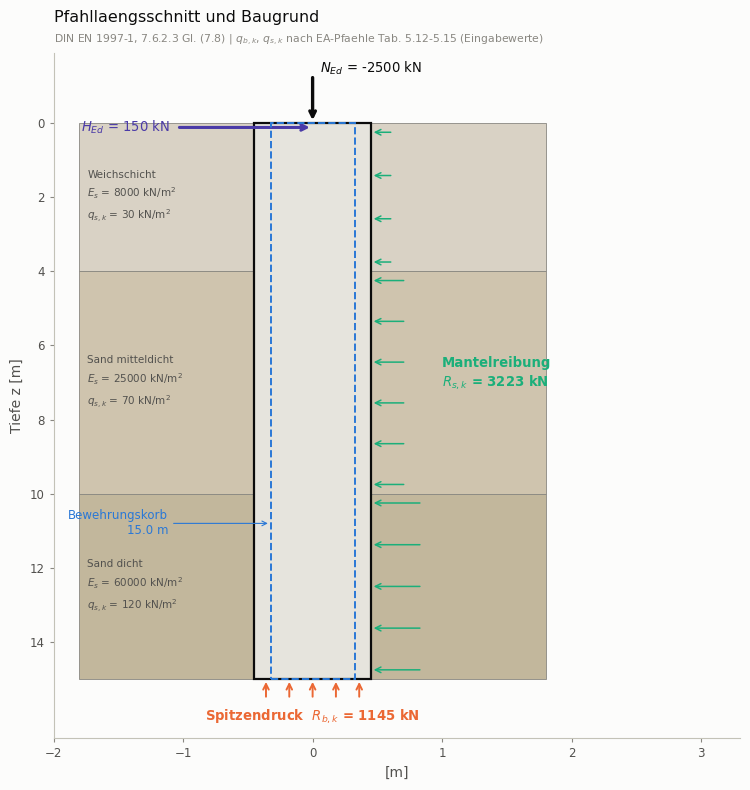

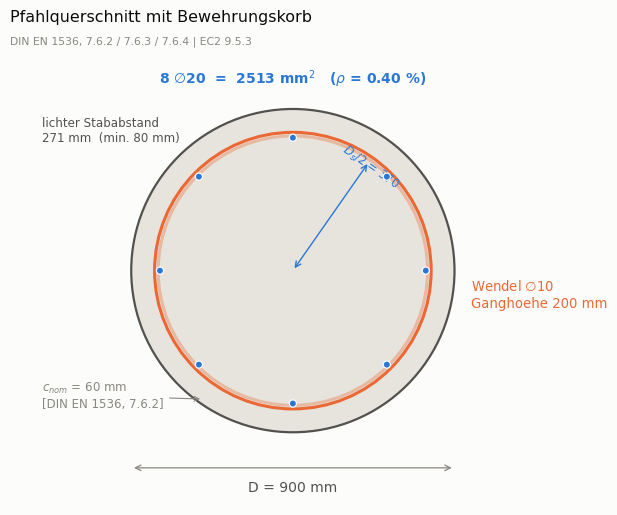

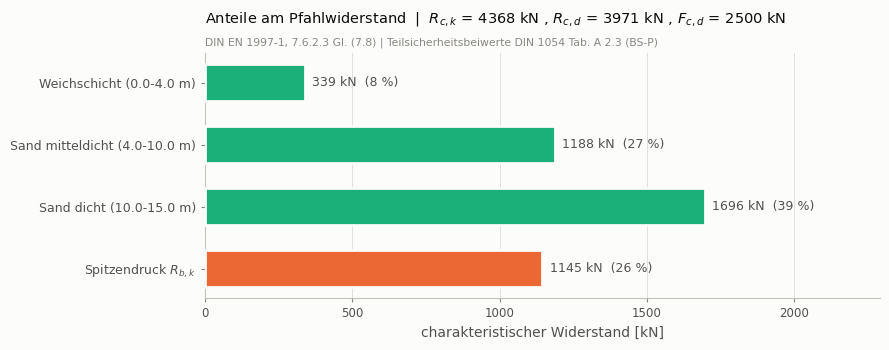

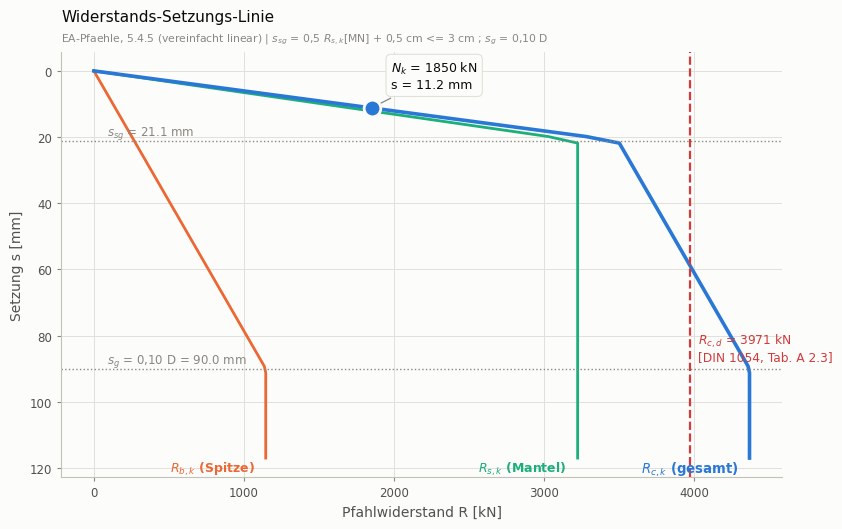

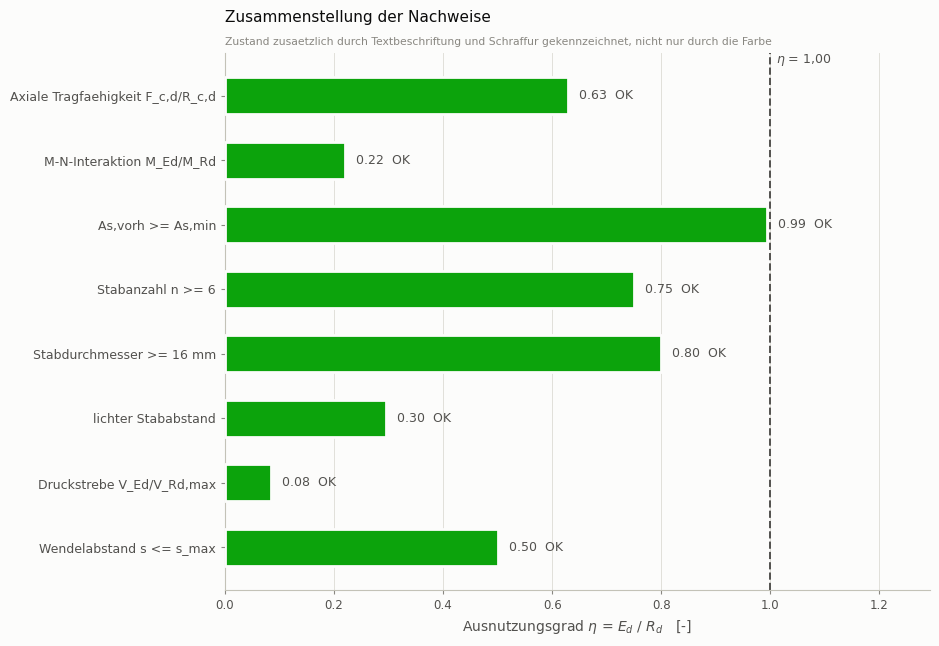

In [15]:
GP.bild_laengsschnitt(ber); plt.show()
GP.bild_querschnitt(ber); plt.show()
GP.bild_tragfaehigkeit(ber); plt.show()
GP.bild_wsl(ber); plt.show()
GP.bild_ausnutzung(ber); plt.show()

---
# Anhang A · Einfluss der Bewehrung auf das Interaktionsdiagramm

Wie verschiebt sich die Umhüllende, wenn der Bewehrungsgrad steigt?

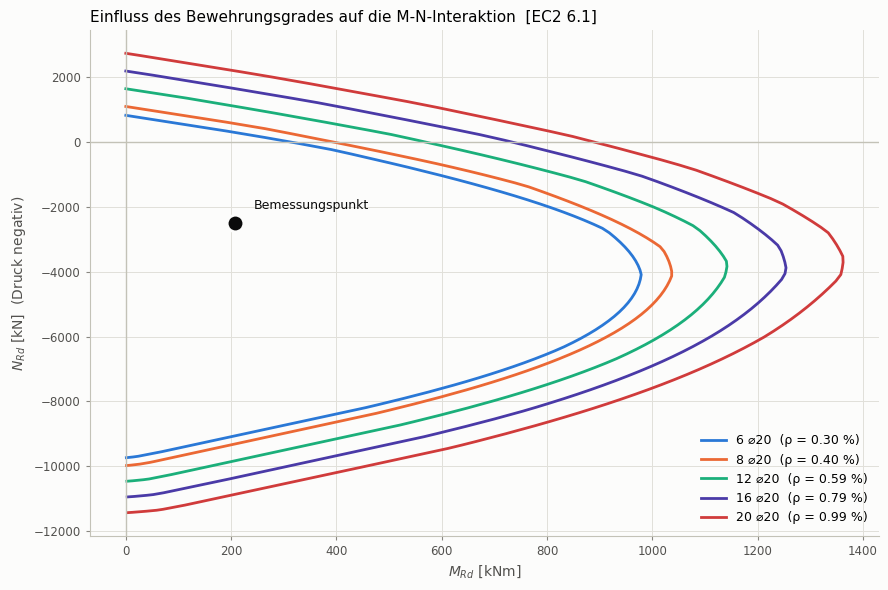

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
for i, n in enumerate([6, 8, 12, 16, 20]):
    qi = Kreisquerschnitt(D=D, c_nom=c_nom, phi_l=phi_l, n_l=n, phi_w=phi_w)
    di = interaktionsdiagramm(qi, C, S, n_punkte=150)
    ax.plot(di["M"], di["N"], lw=2.0,
            color=[G.C1, G.C2, G.C3, G.C4, G.NOK][i],
            label=f"{n} ⌀{phi_l:.0f}  (ρ = {100*qi.rho_l:.2f} %)")
ax.plot([M_Ed], [N_Ed], "o", color=G.INK, ms=12, mec="#fcfcfb", mew=2, zorder=6)
ax.annotate("Bemessungspunkt", (M_Ed, N_Ed), textcoords="offset points",
            xytext=(14, 10), fontsize=9, color=G.INK)
ax.axhline(0, color=G.AXIS, lw=1.0); ax.axvline(0, color=G.AXIS, lw=1.0)
ax.set_xlabel("$M_{Rd}$ [kNm]"); ax.set_ylabel("$N_{Rd}$ [kN]  (Druck negativ)")
ax.set_title("Einfluss des Bewehrungsgrades auf die M-N-Interaktion  [EC2 6.1]",
             loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=9, loc="lower right")
G._stil(ax, grid="both"); plt.tight_layout(); plt.show()

---
# Anhang B · Einfluss der Bettung auf Kopfverschiebung und Biegemoment

Der Steifemodul der **obersten** Schicht bestimmt das Verhalten des horizontal belasteten
Pfahls maßgeblich — dort werden die größten Bettungsspannungen mobilisiert.

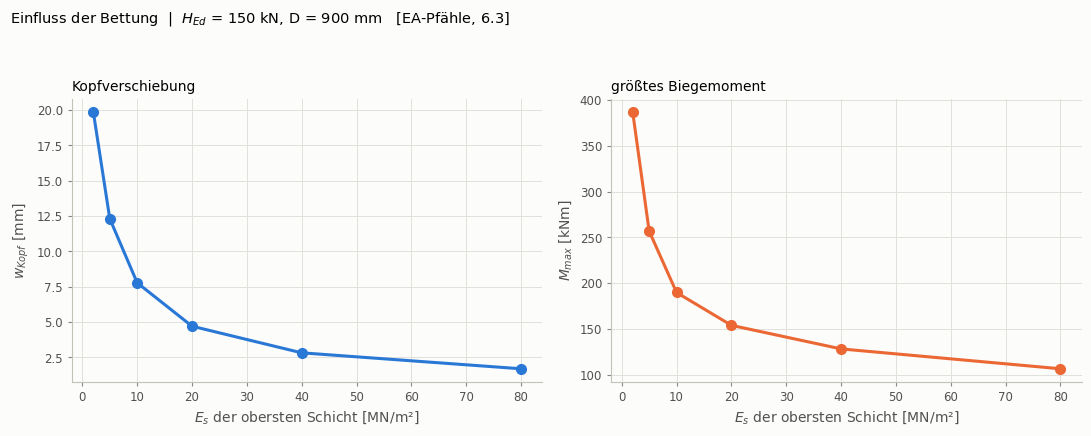

Ein weicherer Boden vergrößert die Kopfverschiebung stark, das Biegemoment
dagegen nur mäßig — es wandert jedoch tiefer in den Pfahl hinein.


In [17]:
Es_werte = np.array([2000., 5000., 10000., 20000., 40000., 80000.])
w_kopf, M_max = [], []
for Es in Es_werte:
    sch = [Bodenschicht(0.0, 4.0, E_s=Es, q_s_k=30.)] + schichten[1:]
    h_ = pfahl_horizontal(L, D_m, EI, sch, H=H_Ed, kopf="frei")
    w_kopf.append(h_.w_kopf); M_max.append(h_.M_max)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.4))
a1.plot(Es_werte/1000, w_kopf, "o-", color=G.C1, lw=2.2, ms=7)
a1.set_xlabel("$E_s$ der obersten Schicht [MN/m²]"); a1.set_ylabel("$w_{Kopf}$ [mm]")
a1.set_title("Kopfverschiebung", loc="left", fontsize=10); G._stil(a1, grid="both")
a2.plot(Es_werte/1000, M_max, "o-", color=G.C2, lw=2.2, ms=7)
a2.set_xlabel("$E_s$ der obersten Schicht [MN/m²]"); a2.set_ylabel("$M_{max}$ [kNm]")
a2.set_title("größtes Biegemoment", loc="left", fontsize=10); G._stil(a2, grid="both")
plt.suptitle(f"Einfluss der Bettung  |  $H_{{Ed}}$ = {H_Ed:.0f} kN, D = {D:.0f} mm"
             "   [EA-Pfähle, 6.3]", x=0.012, ha="left", fontsize=10.5)
plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()
print("Ein weicherer Boden vergrößert die Kopfverschiebung stark, das Biegemoment")
print("dagegen nur mäßig — es wandert jedoch tiefer in den Pfahl hinein.")

---
# Anhang C · Verzeichnis aller verwendeten Normstellen

In [18]:
print(normentabelle())

VERWENDETE NORMSTELLEN - PFAHLBEMESSUNG

--- DIN 1054:2010-12 ---
  A 2.4.7.6.1, Tab. A 2.1                          Teilsicherheitsbeiwerte der Einwirkungen im Nachweis GEO-2: gamma_G = 1,35 ; gamma_Q = 1,50 (BS-P)
  A 7.6.2.2, Tab. A 2.3                            Teilsicherheitsbeiwerte der Pfahlwiderstaende: gamma_b = gamma_s = gamma_t = 1,10 (BS-P) ; Zugpfaehle gamma_s,t = 1,15 (BS-P)

--- DIN EN 1536:2015-10 ---
  1 / 3                                            Anwendungsbereich und Begriffe fuer Bohrpfaehle
  6.3                                              Anforderungen an den Pfahlbeton (Konsistenz, Groesstkorn, Mindestgehalt)
  7.6.2                                            Betondeckung: c_nom >= 60 mm bei D >= 0,6 m; >= 50 mm bei D < 0,6 m; >= 75 mm beim Betonieren unter Stuetzfluessigkeit
  7.6.3                                            Laengsbewehrung: mindestens 6 Staebe, phi >= 16 mm, lichter Abstand >= 100 mm (>= 80 mm bei Groesstkorn <= 20 mm)
  7.6.3, Tab. 4     

---
# Anhang D · Vollständiger Bemessungsbericht

In [19]:
print(bericht_text(ber, mit_normen=False))

BEMESSUNG EINES BOHRPFAHLS
Normen: DIN EN 1536:2015-10 | DIN EN 1997-1 + DIN 1054:2010-12 | EA-Pfaehle | DIN EN 1992-1-1 + NA
Bohrpfahl D = 900 mm , L = 15.00 m | C25/30 | B500B


----------------------------------------------------------------------------------------------------
1. BAUSTOFFE
   Normgrundlage:
      - DIN EN 1992-1-1:2011-01, Abschnitt 3.1.6 (1)P Gl. (3.15) - fcd = alpha_cc fck/gamma_C
      - DIN EN 1536:2015-10, Abschnitt 6.3 - Anforderungen an den Pfahlbeton (Konsistenz, Groesstkorn, Mindestgehalt)
----------------------------------------------------------------------------------------------------
Beton C25/30  [EC2 3.1.2, Tab. 3.1 ; DIN EN 1536, 6.3]
   fck = 25.0 N/mm2   fctm = 2.56 N/mm2   Ecm = 31476 N/mm2
   fcd = alpha_cc fck/gamma_C = 0,85 * 25 / 1,50 = 14.17 N/mm2   [Gl. (3.15)]
   eps_c2 = 2.00 permil   eps_cu2 = 3.50 permil
Betonstahl B500B: fyk = 500 N/mm2   fyd = 434.78 N/mm2   eps_ud = 25 permil

Hinweis DIN EN 1536, 6.3: Pfahlbeton mit weicher bis flie

---

### ⚠️ Umfang und Grenzen

Erfasst: **axiale Tragfähigkeit** (DIN EN 1997-1 7.6 + DIN 1054 A 7.6),
**Widerstands-Setzungs-Linie** (EA-Pfähle 5.4.5), **horizontal belasteter Pfahl**
(Bettungsmodulverfahren, EA-Pfähle 6.3), **M-N-Interaktion des Kreisquerschnitts** (EC2 6.1),
**Längs- und Querbewehrung** (DIN EN 1536 7.6 + EC2 6.2/9.5.3) sowie der **Knicknachweis**
(EA-Pfähle 4.7).

**Nicht** erfasst: Pfahlgruppenwirkung und Gruppenfaktoren (EA-Pfähle 8), negative
Mantelreibung, zyklische und dynamische Einwirkungen, Erdbeben, Hebungen und Setzungen des
Gesamtbauwerks, Ausführungsnormen für Verdrängungs- (DIN EN 12699) und Mikropfähle
(DIN EN 14199).

Die Bettung ist **linear** angesetzt; bei großen Kopfverschiebungen ist ein nichtlineares
p-y-Verfahren zu verwenden und die mobilisierte Bettungsspannung gegen den Erdwiderstand
zu begrenzen (EA-Pfähle 6.4).

$q_{b,k}$ und $q_{s,k}$ sind **Eingabewerte**; sie sind den EA-Pfähle-Tabellen oder einer
Probebelastung zu entnehmen. Alle Ergebnisse sind von einem verantwortlichen Ingenieur
zu prüfen.